# MRMS × HydroFabric — Notebook 2 of 3: MRMS↔HydroFabric Crosswalk & Event/AOI Selection

**This notebook does two jobs:**
1. **Step 2** — build MRMS grid-cell centers for every VPU, spatially join them into
   `catchments_master` (from Notebook 1), and sanity-check/visualize the result. This
   is the full-CONUS crosswalk (every MRMS cell → its catchment/VPU/nexus).
2. **AOI/event selection** — pick one HUC8 interactively, filter the flood-event
   catalog down to that HUC8, and trace each storm to its recording USGS gage and
   that gage's upstream contributing catchments (the "gage-basin" that Notebook 3
   builds MRMS timeseries for).

It loads everything it needs from `hydrofabric_outputs/` (written by Notebook 1) —
it never reopens the full `conus_nextgen.gpkg`. At the end it saves the HUC8/event
selection so **Notebook 3** (per-event MRMS download + timeseries) can pick up from
disk.

**Note on scope:** the original notebook also had an extended side-quest comparing
three ways to keep catchments inside a HUC8 boundary (centroid-in vs. strictly-within
vs. clipped) before settling on centroid-in — that comparison isn't reproduced here
since centroid-in is what the selector below actually uses. It's easy to re-add if
you want to revisit that decision.

## 2.0 Load Notebook 1's outputs

In [1]:
import os
import sys
import warnings
from pathlib import Path

# --- PROJ database fix (same defensive trick as Notebook 1) ---
# proj_data = Path(sys.prefix) / "share" / "proj"
# if proj_data.exists():
#     os.environ["PROJ_DATA"] = str(proj_data)
#     os.environ["PROJ_LIB"] = str(proj_data)

import numpy as np
import pandas as pd
import geopandas as gpd
import pyproj

pyproj.network.set_network_enabled(False)
warnings.filterwarnings("ignore")

NB1_DIR = Path("/projects/mhpi/leoglonz/sub_hourly/data/_mrms_preprocess")
assert NB1_DIR.exists(), f"\u274c {NB1_DIR} not found \u2014 run Notebook 1 first."

catchments_master = gpd.read_parquet(NB1_DIR / "catchments_master.parquet")
network           = pd.read_parquet(NB1_DIR / "network.parquet")
flowpaths         = gpd.read_parquet(NB1_DIR / "flowpaths.parquet")
nexus             = gpd.read_parquet(NB1_DIR / "nexus.parquet")

target_crs = catchments_master.crs   # EPSG:5070

print(f"catchments_master: {len(catchments_master):,} | network: {len(network):,} | "
      f"flowpaths: {len(flowpaths):,} | nexus: {len(nexus):,}")
print("target_crs:", target_crs)

catchments_master: 831,777 | network: 3,461,367 | flowpaths: 828,288 | nexus: 409,122
target_crs: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "NAD83 / Conus Albers", "base_crs": {"name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4269}}, "conversion": {"name": "Conus Albers", "method": {"name": "Albers Equal Area", "id": {"authority": "EPSG", "code": 9822}}, "parameters": [{"name": "Latitude of false origin", "value": 23, "unit": "degree", "id": {"authority": "EPSG", "code": 8821}}, {"name": "Longitude of fals

# Step 2 \u2014 Build the MRMS \u2192 HydroFabric crosswalk

For each VPU, this step generates MRMS grid-cell center points inside that VPU bounding box, reprojects the points to EPSG:5070, and spatially joins them to the hydrofabric catchments.

Each MRMS grid cell is assigned to one catchment using point-in-polygon.

The result is cached by VPU, so the process is resumable.

Important assumptions:

- MRMS grid resolution is 0.01 degrees.
- MRMS grid size is 3500 \u00d7 7000.
- MRMS longitude edges run from -130 to -60.
- MRMS latitude edges run from 20 to 55.
- Cell centers are offset by half a cell.
- `cell_id = row * 7000 + col`.

In [2]:
import shutil
import time

# ------------------------------------------------------------
# MRMS CONUS grid definition
# ------------------------------------------------------------

MRMS_LON_MIN_EDGE = -130.0
MRMS_LAT_MAX_EDGE = 55.0

MRMS_RES = 0.01
MRMS_NLON = 7000
MRMS_NLAT = 3500

HALF = MRMS_RES / 2.0


def mrms_centers_for_bbox(west, east, south, north, pad=1):
    """
    Return MRMS cell centers covering a bounding box.

    Output:
    row, col, lon, lat
    """

    i0 = int(np.floor((west - MRMS_LON_MIN_EDGE - HALF) / MRMS_RES)) - pad
    i1 = int(np.ceil((east - MRMS_LON_MIN_EDGE - HALF) / MRMS_RES)) + pad

    j0 = int(np.floor((MRMS_LAT_MAX_EDGE - HALF - north) / MRMS_RES)) - pad
    j1 = int(np.ceil((MRMS_LAT_MAX_EDGE - HALF - south) / MRMS_RES)) + pad

    i0 = max(0, i0)
    i1 = min(MRMS_NLON - 1, i1)

    j0 = max(0, j0)
    j1 = min(MRMS_NLAT - 1, j1)

    if i1 < i0 or j1 < j0:
        return None

    cols = np.arange(i0, i1 + 1)
    rows = np.arange(j0, j1 + 1)

    lon = MRMS_LON_MIN_EDGE + HALF + cols * MRMS_RES
    lat = MRMS_LAT_MAX_EDGE - HALF - rows * MRMS_RES

    LON, LAT = np.meshgrid(lon, lat)
    COL, ROW = np.meshgrid(cols, rows)

    return ROW.ravel(), COL.ravel(), LON.ravel(), LAT.ravel()


# ------------------------------------------------------------
# Cache setup
# ------------------------------------------------------------

CACHE = Path("mrms_crosswalk_cache")
CACHE.mkdir(exist_ok=True)

COMBINED = CACHE / "mrms_hf_crosswalk_conus.parquet"

CARRY = [
    "divide_id",
    "vpuid",
    "nexus_id",
    "nexus_type",
    "is_terminal",
    "geometry"
]

# To force a full rebuild, uncomment these two lines:
# shutil.rmtree(CACHE, ignore_errors=True)
# CACHE.mkdir(exist_ok=True)


# ------------------------------------------------------------
# Build VPU-batched crosswalk
# ------------------------------------------------------------

vpus = sorted(catchments_master["vpuid"].dropna().unique())

parts = []
t_all = time.time()

for vpu in vpus:

    out = CACHE / f"crosswalk_vpu_{vpu}.parquet"

    if out.exists():
        df_cached = pd.read_parquet(out)
        parts.append(df_cached)
        print(f"{vpu}: cached ({len(df_cached):,})")
        continue

    sub = catchments_master[catchments_master["vpuid"] == vpu]

    west, south, east, north = sub.to_crs(4326).total_bounds

    res = mrms_centers_for_bbox(west, east, south, north)

    if res is None:
        print(f"{vpu}: no grid cells in bbox")
        continue

    row, col, lon, lat = res

    pts = gpd.GeoDataFrame(
        {
            "cell_id": row.astype(np.int64) * MRMS_NLON + col.astype(np.int64),
            "row": row.astype(np.int32),
            "col": col.astype(np.int32),
            "lon": lon,
            "lat": lat
        },
        geometry=gpd.points_from_xy(lon, lat),
        crs=4326
    ).to_crs(5070)

    joined = gpd.sjoin(
        pts,
        sub[CARRY],
        how="inner",
        predicate="within"
    )

    df = (
        pd.DataFrame(
            joined.drop(columns=["geometry", "index_right"])
        )
        .drop_duplicates("cell_id")
    )

    df.to_parquet(out, index=False)
    parts.append(df)

    print(
        f"{vpu}: {len(pts):,} grid pts -> {len(df):,} in catchments "
        f"({100 * len(df) / len(pts):.0f}% land)"
    )


crosswalk = (
    pd.concat(parts, ignore_index=True)
    .drop_duplicates("cell_id")
)

crosswalk.to_parquet(COMBINED, index=False)

print(
    f"\nDONE in {time.time() - t_all:.0f}s | "
    f"CONUS crosswalk: {len(crosswalk):,} MRMS cells -> {COMBINED}"
)

01: 488,345 grid pts -> 191,744 in catchments (39% land)
02: 764,744 grid pts -> 295,607 in catchments (39% land)
03N: 514,800 grid pts -> 247,755 in catchments (48% land)
03S: 421,860 grid pts -> 166,532 in catchments (39% land)
03W: 360,288 grid pts -> 230,369 in catchments (64% land)
04: 1,558,200 grid pts -> 356,473 in catchments (23% land)
05: 823,546 grid pts -> 438,116 in catchments (53% land)
06: 236,482 grid pts -> 105,361 in catchments (45% land)
07: 1,249,986 grid pts -> 542,285 in catchments (43% land)
08: 546,273 grid pts -> 275,627 in catchments (50% land)
09: 765,478 grid pts -> 258,459 in catchments (34% land)
10L: 1,285,536 grid pts -> 573,082 in catchments (45% land)
10U: 1,457,012 grid pts -> 939,001 in catchments (64% land)
11: 1,354,650 grid pts -> 643,005 in catchments (47% land)
12: 955,488 grid pts -> 429,054 in catchments (45% land)
13: 1,595,488 grid pts -> 533,794 in catchments (33% land)
14: 534,482 grid pts -> 306,112 in catchments (57% land)
15: 667,089 gr

## 2.1 Sanity checks

These checks confirm that the crosswalk is usable.

Expected:

- `unique cell_id` should equal total rows.
- There should be no nulls in `divide_id`, `vpuid`, or `nexus_id`.
- Some very small catchments may receive zero MRMS cells. That is expected because the MRMS grid is about 1 km.

In [3]:
cw = pd.read_parquet(COMBINED)

print(f"total MRMS cells in crosswalk  : {len(cw):,}")
print(f"unique cell_id should = total  : {cw['cell_id'].nunique():,}")

print(
    f"unique catchments hit          : "
    f"{cw['divide_id'].nunique():,} of "
    f"{catchments_master['divide_id'].nunique():,}"
)

print(
    f"nulls -> divide_id {cw['divide_id'].isna().sum()}, "
    f"vpuid {cw['vpuid'].isna().sum()}, "
    f"nexus_id {cw['nexus_id'].isna().sum()}"
)

print(
    f"\nmean MRMS cells per catchment  : "
    f"{len(cw) / cw['divide_id'].nunique():.1f}"
)

print(
    f"catchments with 0 cells        : "
    f"{catchments_master['divide_id'].nunique() - cw['divide_id'].nunique():,}"
)

print("\nMRMS cells per VPU:")
print(
    cw.groupby("vpuid")
    .size()
    .sort_values(ascending=False)
    .to_string()
)

total MRMS cells in crosswalk  : 8,647,251
unique cell_id should = total  : 8,647,251
unique catchments hit          : 821,533 of 831,777
nulls -> divide_id 0, vpuid 0, nexus_id 0

mean MRMS cells per catchment  : 10.5
catchments with 0 cells        : 10,244

MRMS cells per VPU:
vpuid
17     942668
10U    938992
11     642995
10L    573076
07     542272
13     533793
05     438110
12     429047
18     426790
16     385700
15     359798
04     356472
14     306107
02     295603
08     275622
09     258458
03N    247754
03W    230369
01     191744
03S    166532
06     105349


## 2.2 Correctness visual \u2014 cells colored by assigned catchment

This visual checks whether MRMS grid cells are being assigned to the correct catchments.

Correct behavior:

- The target catchment boundary should contain cells assigned to that catchment.
- Cell colors should switch at catchment borders.
- The red boundary should line up with the assigned MRMS cells.

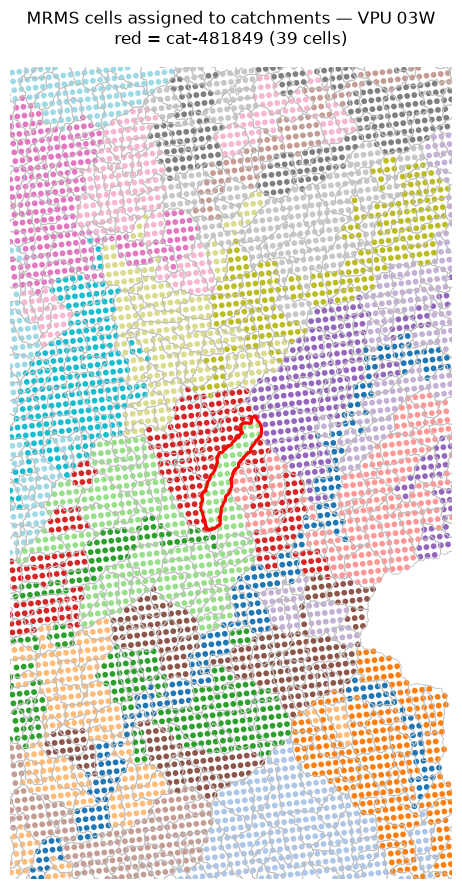

In [4]:
import matplotlib.pyplot as plt

VPU_DEMO = "03W"

cwv = pd.read_parquet(CACHE / f"crosswalk_vpu_{VPU_DEMO}.parquet")

cwg = gpd.GeoDataFrame(
    cwv,
    geometry=gpd.points_from_xy(cwv.lon, cwv.lat),
    crs=4326
).to_crs(5070)

cats = catchments_master[catchments_master["vpuid"] == VPU_DEMO]

counts = cwv["divide_id"].value_counts()

target_id = counts[(counts > 8) & (counts < 40)].index[0]

target = cats[cats["divide_id"] == target_id]

minx, miny, maxx, maxy = target.total_bounds

px = (maxx - minx) * 3 + 800
py = (maxy - miny) * 3 + 800

xlim = (minx - px, maxx + px)
ylim = (miny - py, maxy + py)

local_cats = cats.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
local_pts = cwg.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]

fig, ax = plt.subplots(figsize=(9, 9))

local_cats.boundary.plot(
    ax=ax,
    color="0.75",
    linewidth=0.6
)

local_pts.plot(
    ax=ax,
    column="divide_id",
    cmap="tab20",
    markersize=10,
    legend=False
)

target.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2.2
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_axis_off()

ax.set_title(
    f"MRMS cells assigned to catchments \u2014 VPU {VPU_DEMO}\n"
    f"red = {target_id} ({counts[target_id]} cells)"
)

plt.tight_layout()
plt.show()

## 2.3 Correctness visual \u2014 catchment, cells, and draining nexus

This visual checks the catchment-to-nexus relationship.

The magenta star is the target catchment's draining nexus. It should sit near the outlet of the red target catchment.

Black dots are neighboring nexus points.

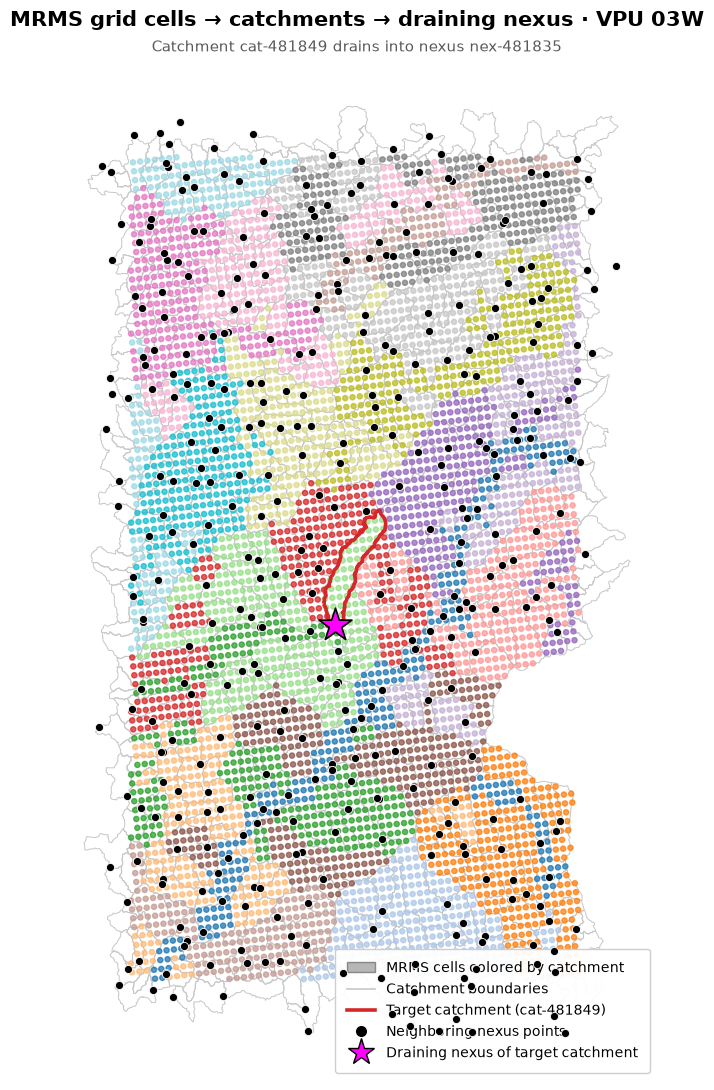

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# nexus already carries geometry (loaded from Notebook 1's output) -- no need
# to reopen the GeoPackage for it.
nexus_geom = nexus

if "nexus_id" not in local_cats.columns:
    local_cats = local_cats.merge(
        catchments_master[["divide_id", "nexus_id"]],
        on="divide_id",
        how="left"
    )

local_nexus = nexus_geom[
    nexus_geom["id"]
    .astype(str)
    .isin(local_cats["nexus_id"].astype(str))
]

target_nex_id = catchments_master.loc[
    catchments_master["divide_id"] == target_id,
    "nexus_id"
].iloc[0]

target_nex = nexus_geom[
    nexus_geom["id"].astype(str) == str(target_nex_id)
]

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor("white")

local_cats.boundary.plot(
    ax=ax,
    color="0.78",
    linewidth=0.7,
    zorder=1
)

local_pts.plot(
    ax=ax,
    column="divide_id",
    cmap="tab20",
    markersize=14,
    alpha=0.75,
    legend=False,
    zorder=2
)

target.boundary.plot(
    ax=ax,
    color="#d62728",
    linewidth=2.6,
    zorder=5
)

local_nexus.plot(
    ax=ax,
    color="black",
    markersize=34,
    edgecolor="white",
    linewidth=0.6,
    zorder=6
)

target_nex.plot(
    ax=ax,
    color="magenta",
    marker="*",
    markersize=620,
    edgecolor="black",
    linewidth=1.2,
    zorder=7
)

ax.set_aspect("equal")
ax.set_axis_off()

ax.set_title(
    f"MRMS grid cells \u2192 catchments \u2192 draining nexus \u00b7 VPU {VPU_DEMO}",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.text(
    0.5,
    1.005,
    f"Catchment {target_id} drains into nexus {target_nex_id}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="0.35"
)

ax.legend(
    handles=[
        Patch(
            facecolor="0.6",
            edgecolor="0.4",
            alpha=0.7,
            label="MRMS cells colored by catchment"
        ),
        Line2D(
            [0],
            [0],
            color="0.78",
            lw=1.2,
            label="Catchment boundaries"
        ),
        Line2D(
            [0],
            [0],
            color="#d62728",
            lw=2.6,
            label=f"Target catchment ({target_id})"
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="black",
            markeredgecolor="white",
            markersize=9,
            label="Neighboring nexus points"
        ),
        Line2D(
            [0],
            [0],
            marker="*",
            color="none",
            markerfacecolor="magenta",
            markeredgecolor="black",
            markersize=20,
            label="Draining nexus of target catchment"
        )
    ],
    loc="lower right",
    frameon=True,
    framealpha=0.95,
    fontsize=10,
    borderpad=0.9,
    edgecolor="0.8"
)

plt.tight_layout()
plt.show()

# Section 3 \u2014 Pick a HUC8 (AOI selector)

Interactive dropdown: type to filter, pick a HUC8, click **Select / Continue**
(or press Enter). This locks in `selected_huc8` and `huc8_catchments`, which
everything below depends on.

Requires a local `HUC8_US.shp` (+ sidecar files) in the working directory.

In [6]:
# ============================================================
# HUC8 selector -- data prep (run once)
# ============================================================
from shapely.geometry import box
# https://www.hydroshare.org/resource/b832a6c2f96541808444ec9562c5247e/
HUC8_SHP = Path("/projects/mhpi/leoglonz/sub_hourly/data/huc8_top15/shape/HUC8_US.shp")
assert HUC8_SHP.exists(), f"\u274c Shapefile not found: {HUC8_SHP.resolve()}"

# -----------------------------
# 1. Read HUC8 polygons, reproject to hydrofabric CRS
# -----------------------------
huc8 = gpd.read_file(HUC8_SHP).to_crs(target_crs)

# -----------------------------
# 2. Auto-detect the HUC8 code column and the name column
# -----------------------------
def _pick_col(cols, candidates):
    lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    return None

HUC8_CODE_COL = _pick_col(
    huc8.columns,
    ["huc8", "huc_8", "huc8_code", "huc", "huc_code"]
)
HUC8_NAME_COL = _pick_col(
    huc8.columns,
    ["name", "huc8_name", "hu_8_name", "wbd_name", "subbasin"]
)

print("Detected HUC8 code column:", HUC8_CODE_COL)
print("Detected HUC8 name column:", HUC8_NAME_COL)
print("All columns:", list(huc8.columns))

# Fallbacks if detection fails -- edit manually if either is None
if HUC8_CODE_COL is None:
    HUC8_CODE_COL = huc8.columns[0]
    print(f"\u26a0\ufe0f HUC8 code not auto-detected; using '{HUC8_CODE_COL}'")
if HUC8_NAME_COL is None:
    HUC8_NAME_COL = HUC8_CODE_COL
    print(f"\u26a0\ufe0f HUC8 name not auto-detected; using '{HUC8_NAME_COL}'")

# Build a clean label = "code -- name" so the dropdown is unambiguous
# (HUC8 names are not always unique; codes are).
huc8["_label"] = (
    huc8[HUC8_CODE_COL].astype(str).str.zfill(8)
    + " \u2014 "
    + huc8[HUC8_NAME_COL].astype(str)
)
huc8 = huc8.sort_values("_label").reset_index(drop=True)

# -----------------------------
# 3. Catchment centroids (precompute once)
# -----------------------------
cat_centroids = catchments_master[["divide_id", "vpuid", "geometry"]].copy()
cat_centroids["geometry"] = cat_centroids.geometry.centroid

# -----------------------------
# 4. VPU bounding boxes for subplot 1 (cached)
# -----------------------------
vpu_box_cache = CACHE / "vpu_bounding_boxes.parquet"
if vpu_box_cache.exists():
    vpu_boxes = gpd.read_parquet(vpu_box_cache)
else:
    recs = []
    for vpu, grp in catchments_master.groupby("vpuid"):
        bxmin, bymin, bxmax, bymax = grp.total_bounds
        recs.append({"vpuid": vpu, "geometry": box(bxmin, bymin, bxmax, bymax)})
    vpu_boxes = gpd.GeoDataFrame(recs, geometry="geometry", crs=target_crs)
    vpu_boxes.to_parquet(vpu_box_cache, index=False)
if vpu_boxes.crs != target_crs:
    vpu_boxes = vpu_boxes.to_crs(target_crs)

print(f"\n\u2705 Ready: {len(huc8):,} HUC8 polygons, "
      f"{len(cat_centroids):,} catchment centroids")

Detected HUC8 code column: HUC8
Detected HUC8 name column: NAME
All columns: ['TNMID', 'METASOURCE', 'SOURCEDATA', 'SOURCEORIG', 'SOURCEFEAT', 'LOADDATE', 'GNIS_ID', 'AREAACRES', 'AREASQKM', 'STATES', 'HUC8', 'NAME', 'Shape_Leng', 'Shape_Area', 'geometry']

✅ Ready: 2,139 HUC8 polygons, 831,777 catchment centroids


In [7]:
import sys
!{sys.executable} -m pip install -q ipywidgets

In [8]:
# ============================================================
# HUC8 selector -- MULTI-select. Search to filter -> pick one ->
# "Add to selection" -> repeat for each HUC8 you want -> "Confirm
# All / Plot" to lock in every selected HUC8 and plot them all
# together on one CONUS-extent map.
# ============================================================
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

ALL_LABELS = huc8["_label"].tolist()

search = widgets.Text(
    value="",
    placeholder="Type any part of a HUC8 name or code, then pick below…",
    description="Search:",
    layout=widgets.Layout(width="600px"),
    style={"description_width": "initial"},
)
dropdown = widgets.Dropdown(
    options=ALL_LABELS,
    description="HUC8:",
    layout=widgets.Layout(width="600px"),
    style={"description_width": "initial"},
)
add_btn = widgets.Button(
    description="Add to selection", button_style="info", icon="plus",
    layout=widgets.Layout(width="200px"),
)
remove_btn = widgets.Button(
    description="Remove selected", button_style="warning", icon="minus",
    layout=widgets.Layout(width="200px"),
)
confirm_btn = widgets.Button(
    description="Confirm All / Plot", button_style="success", icon="check",
    layout=widgets.Layout(width="200px"),
)
match_count = widgets.Label(value=f"{len(ALL_LABELS):,} HUC8s")
picked_box = widgets.SelectMultiple(
    options=[], description="Selected:",
    layout=widgets.Layout(width="600px", height="150px"),
    style={"description_width": "initial"},
)
out = widgets.Output()

# results start empty until the user confirms
selected_huc8s = None          # GeoDataFrame, one row per chosen HUC8
huc8_catchments_by_huc8 = None # dict[huc8_code -> catchments GeoDataFrame]
_picked_labels = []             # running list, in add-order


def _filter(change=None):
    q = search.value.strip().lower()
    matches = ALL_LABELS if q == "" else [l for l in ALL_LABELS if q in l.lower()]
    current = dropdown.value
    dropdown.options = matches
    match_count.value = f"{len(matches):,} match" + ("" if len(matches) == 1 else "es")
    if current in matches:
        dropdown.value = current
    elif matches:
        dropdown.value = matches[0]


def _add(_=None):
    label = dropdown.value
    if label and label not in _picked_labels:
        _picked_labels.append(label)
        picked_box.options = list(_picked_labels)


def _remove(_=None):
    for label in picked_box.value:
        if label in _picked_labels:
            _picked_labels.remove(label)
    picked_box.options = list(_picked_labels)


def confirm(_=None):
    """Plot + lock in ALL currently-picked HUC8s together."""
    out.clear_output(wait=True)
    with out:
        if not _picked_labels:
            print("No HUC8s added yet -- use 'Add to selection' first.")
            return

        sel = huc8[huc8["_label"].isin(_picked_labels)].copy()
        sel["huc8_code"] = sel[HUC8_CODE_COL].astype(str).str.zfill(8)

        cats_by_huc8 = {}
        for _, row in sel.iterrows():
            code = row["huc8_code"]
            geom = row.geometry
            inside = cat_centroids[cat_centroids.within(geom)]
            cats_by_huc8[code] = catchments_master[
                catchments_master["divide_id"].isin(inside["divide_id"])
            ].copy()

        # ---- CONUS-extent plot: every selected HUC8 highlighted together ----
        fig, ax = plt.subplots(figsize=(14, 9))
        fig.patch.set_facecolor("white")

        vpu_boxes.boundary.plot(ax=ax, color="0.85", linewidth=0.5, zorder=1)

        cmap = plt.get_cmap("tab10")
        for i, (_, row) in enumerate(sel.iterrows()):
            color = cmap(i % 10)
            gpd.GeoSeries([row.geometry], crs=sel.crs).boundary.plot(
                ax=ax, color=color, linewidth=2.2, zorder=5
            )
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            ax.annotate(row["huc8_code"], (cx, cy), fontsize=8, fontweight="bold",
                        color=color, ha="center", zorder=6)

        ax.set_title(
            f"{len(sel)} HUC8(s) selected, plotted at CONUS extent",
            fontweight="bold"
        )
        ax.set_axis_off()
        ax.set_aspect("equal")
        plt.tight_layout()
        plt.show()

        global selected_huc8s, huc8_catchments_by_huc8
        selected_huc8s = sel
        huc8_catchments_by_huc8 = cats_by_huc8

        print(f"✅ Confirmed {len(sel)} HUC8(s):")
        for _, row in sel.iterrows():
            n_cats = len(cats_by_huc8[row["huc8_code"]])
            print(f"   {row['huc8_code']} — {row['_label']}  ({n_cats:,} catchments)")


search.observe(_filter, names="value")
add_btn.on_click(_add)
remove_btn.on_click(_remove)
confirm_btn.on_click(confirm)

display(
    widgets.HBox([search, match_count]),
    widgets.HBox([dropdown, add_btn]),
    widgets.HBox([picked_box, remove_btn]),
    confirm_btn,
    out,
)

Button(button_style='success', description='Confirm All / Plot', icon='check', layout=Layout(width='200px'), s…

Output()

In [10]:
# ============================================================
# Attach the per-HUC8 events CSV for every selected HUC8.
# Expects one file per HUC8, named huc8_<code>_combined_events.csv
# (same event_id/STAID/BEGIN_DATE_TIME/... schema used earlier).
# Tags every row with huc8_code so downstream steps (and the
# multi-HUC8 downloader) know which HUC8 each event belongs to.
# ============================================================
assert selected_huc8s is not None, "Run the HUC8 selector above and click Confirm first."

events_by_huc8 = {}
missing_files = []

for code in selected_huc8s["huc8_code"]:
    csv_path = Path(f"/projects/mhpi/leoglonz/sub_hourly/data/huc8_top15/huc8_events/huc8_{code}_combined_events.csv")
    if not csv_path.exists():
        missing_files.append(csv_path)
        continue
    df = pd.read_csv(csv_path)
    df["huc8_code"] = code
    events_by_huc8[code] = df

if missing_files:
    print("⚠️ Missing events CSVs for these HUC8s (skipped):")
    for p in missing_files:
        print(f"   {p}")

events_multi = pd.concat(events_by_huc8.values(), ignore_index=True)
events_multi = events_multi.rename(columns={
    "event_id": "storm_index",
    "BEGIN_DATE_TIME": "begin",
    "END_DATE_TIME": "end",
})
# keep storm_index unique across HUC8s in case event_id repeats per file
events_multi["storm_index"] = (
    events_multi["huc8_code"] + "_" + events_multi["storm_index"].astype(str)
)

print(f"Loaded events for {len(events_by_huc8)}/{len(selected_huc8s)} HUC8(s)")
print(f"Combined rows: {len(events_multi):,}")
events_multi.groupby("huc8_code").size().rename("n_events")

Loaded events for 1/1 HUC8(s)
Combined rows: 5,388


huc8_code
03020201    5388
Name: n_events, dtype: int64

In [13]:
OUT_DIR2 = Path("/projects/mhpi/leoglonz/sub_hourly/data/_mrms_preprocess")
OUT_DIR2.mkdir(exist_ok=True)

selected_huc8s.to_parquet(OUT_DIR2 / "selected_huc8s_multi.parquet", index=False)
events_multi.to_csv(OUT_DIR2 / "events_multi.csv", index=False)

print(f"Saved {len(selected_huc8s)} HUC8s -> selected_huc8s_multi.parquet")
print(f"Saved {len(events_multi):,} events -> events_multi.csv")

Saved 1 HUC8s -> selected_huc8s_multi.parquet
Saved 5,388 events -> events_multi.csv


### 3.1 Re-plot the selection (optional)

Same information as the selector's own plot, redrawn with VPU labels and a
legend -- handy if you're reopening the notebook and just want to confirm what
`selected_huc8` currently is without re-running the widget.

# Section 4 \u2014 Flood events inside the selected HUC8

Filters the flood-event catalog to storms whose centroid **and** recording gage
both fall inside `selected_huc8`. Produces `events` (full catalog, flagged) and
`events_in_huc8` / `huc8_events` (the filtered subset).

### 3.5 Build `events` + `new_gages` from the USGS event table

Replaces `final_events (6).csv` + `gages2_lt1000km2.csv` with `upper_neuse_events_usgs.csv` (`event_id, STAID, BEGIN_DATE_TIME, END_DATE_TIME, gage_lat, gage_lon, ...`). This file has **no storm centroid** — each event is already anchored to a known recording gage. We set `centroid_lat/lon = gage_lat/gage_lon` so Section 4's HUC8 filter and Section 5's storm→gage trace collapse to "find this exact gage" (hops = 0), which is correct: the recording gage is already known here, not something to discover. Every cell below this one still runs **unmodified**.

In [8]:
# # ============================================================
# # SHIM v2: build 'events' and 'new_gages' from the USGS-derived
# # event table (event_id, STAID, BEGIN_DATE_TIME, END_DATE_TIME,
# # gage_lat, gage_lon, ...). No storm centroid exists in this file --
# # each event IS anchored to a known gage, so we set
# # centroid_lat/lon = gage_lat/lon. This makes Section 4's HUC8 filter
# # and Section 5's storm->gage trace collapse to "find this gage
# # itself" (hops = 0) -- exactly correct, since the recording gage is
# # already known and doesn't need to be discovered.
# # Writes final_events (6).csv / gages2_lt1000km2.csv so every
# # downstream cell in this notebook runs unmodified.
# # ============================================================
# MERGED_CSV = Path("upper_neuse_events_usgs.csv")
# assert MERGED_CSV.exists(), f"\u274c Not found: {MERGED_CSV.resolve()}"

# merged = pd.read_csv(MERGED_CSV)

# # ---- 1. events (matches final_events (6).csv schema) ----
# events = merged.rename(columns={
#     "event_id":        "storm_index",
#     "BEGIN_DATE_TIME":  "begin",
#     "END_DATE_TIME":    "end",
#     "STAID":            "usgs_gage_id",
# }).copy()

# # No storm centroid in this data -- the event IS the gage.
# events["centroid_lat"] = events["gage_lat"]
# events["centroid_lon"] = events["gage_lon"]

# # Notebook 3's gage_event_table export expects a "cluster_id" tag column
# # (only present in the old final_events (6).csv schema) -- alias it to
# # storm_index so that cell runs unmodified too.
# events["cluster_id"] = events["storm_index"]

# events.to_csv("final_events (6).csv", index=False)
# print(f"events    -> final_events (6).csv      ({len(events):,} rows)")

# # ---- 2. new_gages (matches gages2_lt1000km2.csv schema) ----
# new_gages = (
#     merged[["STAID", "gage_lat", "gage_lon"]]
#     .drop_duplicates(subset="STAID")
#     .rename(columns={"gage_lat": "LAT_GAGE", "gage_lon": "LNG_GAGE"})
#     .copy()
# )
# new_gages.insert(1, "STATID", new_gages["STAID"])  # placeholder, unused downstream
# new_gages["DRAIN_SQKM"] = np.nan  # not provided by this file

# new_gages.to_csv("gages2_lt1000km2.csv", index=False)
# print(f"new_gages -> gages2_lt1000km2.csv      ({len(new_gages):,} rows)")


events    -> final_events (6).csv      (5,388 rows)
new_gages -> gages2_lt1000km2.csv      (12 rows)


Loaded 5,388 event rows

HUC8: 02030102 — Bronx
Rule: storm centroid AND gage both inside
  centroid inside : 0
  gage inside     : 0
  selected events : 0


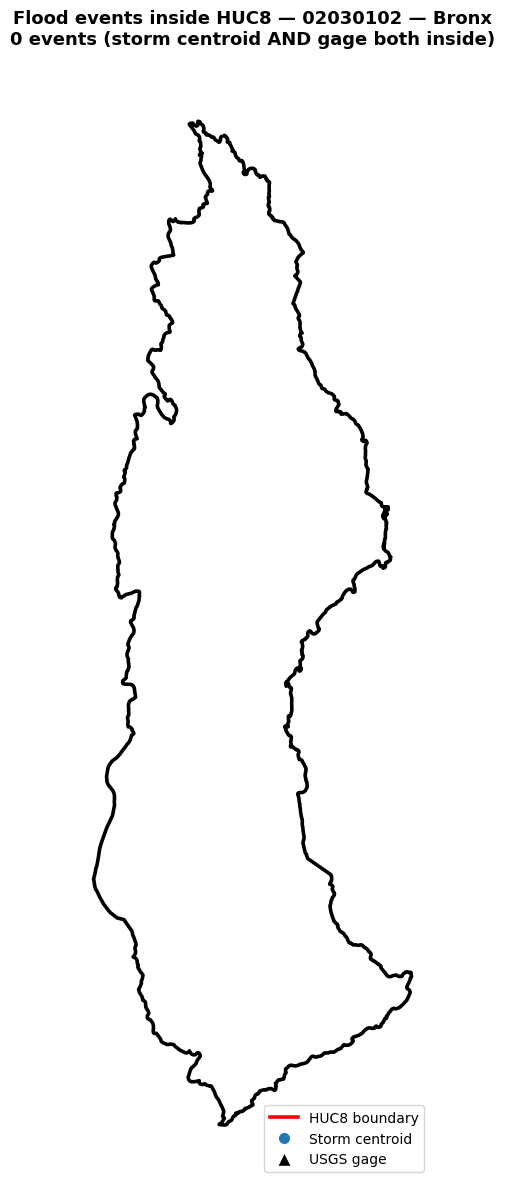


Saved -> huc8_events (0 rows)


In [9]:
# # ============================================================
# # Select flood events whose storm centroid AND gage both fall
# # inside the selected HUC8. Plot = HUC8 boundary + event points.
# #
# # Requires: selected_huc8  (from the selector cell)
# # ============================================================
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# assert selected_huc8 is not None, "\u274c Confirm a HUC8 in the selector cell first."

# EVENTS_CSV = Path("final_events (6).csv")
# assert EVENTS_CSV.exists(), f"\u274c Not found: {EVENTS_CSV.resolve()}"

# sel = selected_huc8
# sel_label = sel["_label"].iloc[0]
# sel_geom = sel.geometry.iloc[0]

# # Require BOTH centroid and gage inside? True = strict (both), False = either
# REQUIRE_BOTH = True

# # -----------------------------
# # 1. Load events
# # -----------------------------
# events = pd.read_csv(EVENTS_CSV)
# print(f"Loaded {len(events):,} event rows")

# # numeric coords
# for c in ["centroid_lat", "centroid_lon", "gage_lat", "gage_lon"]:
#     events[c] = pd.to_numeric(events[c], errors="coerce")

# # -----------------------------
# # 2. Build point layers (lon/lat -> HUC8 CRS) and test containment
# # -----------------------------
# def _points_in(df, lon_col, lat_col):
#     ok = df[[lon_col, lat_col]].notna().all(axis=1)
#     gdf = gpd.GeoDataFrame(
#         df.loc[ok].copy(),
#         geometry=gpd.points_from_xy(df.loc[ok, lon_col], df.loc[ok, lat_col]),
#         crs="EPSG:4326",
#     ).to_crs(target_crs)
#     inside_mask = gdf.within(sel_geom)
#     return gdf, inside_mask

# centroid_gdf, centroid_inside = _points_in(events, "centroid_lon", "centroid_lat")
# gage_gdf,     gage_inside     = _points_in(events, "gage_lon",     "gage_lat")

# # map containment back onto the original rows by index
# events["centroid_in_huc8"] = False
# events.loc[centroid_gdf.index[centroid_inside], "centroid_in_huc8"] = True

# events["gage_in_huc8"] = False
# events.loc[gage_gdf.index[gage_inside], "gage_in_huc8"] = True

# # -----------------------------
# # 3. Select events
# # -----------------------------
# if REQUIRE_BOTH:
#     sel_mask = events["centroid_in_huc8"] & events["gage_in_huc8"]
#     rule = "storm centroid AND gage both inside"
# else:
#     sel_mask = events["centroid_in_huc8"] | events["gage_in_huc8"]
#     rule = "storm centroid OR gage inside"

# events_in_huc8 = events[sel_mask].copy()

# print(f"\nHUC8: {sel_label}")
# print(f"Rule: {rule}")
# print(f"  centroid inside : {events['centroid_in_huc8'].sum():,}")
# print(f"  gage inside     : {events['gage_in_huc8'].sum():,}")
# print(f"  selected events : {len(events_in_huc8):,}")

# # point layers limited to the selected events (for plotting)
# centroid_sel = centroid_gdf.loc[centroid_gdf.index.isin(events_in_huc8.index)]
# gage_sel     = gage_gdf.loc[gage_gdf.index.isin(events_in_huc8.index)]

# # ============================================================
# # 4. Plot -- HUC8 boundary only + marked events
# # ============================================================
# fig, ax = plt.subplots(figsize=(12, 12))
# fig.patch.set_facecolor("white")

# sel.boundary.plot(ax=ax, color="black", linewidth=2.6, zorder=5)

# centroid_sel.plot(ax=ax, color="tab:blue", markersize=45,
#                   marker="o", edgecolor="white", linewidth=0.5,
#                   zorder=6, label="Storm centroid")
# gage_sel.plot(ax=ax, color="black", markersize=70,
#               marker="^", edgecolor="white", linewidth=0.5,
#               zorder=7, label="USGS gage")

# minx, miny, maxx, maxy = sel.total_bounds
# padx = (maxx - minx) * 0.05 + 200
# pady = (maxy - miny) * 0.05 + 200
# ax.set_xlim(minx - padx, maxx + padx)
# ax.set_ylim(miny - pady, maxy + pady)

# ax.set_title(
#     f"Flood events inside HUC8 \u2014 {sel_label}\n"
#     f"{len(events_in_huc8):,} events ({rule})",
#     fontsize=13, fontweight="bold"
# )
# ax.set_axis_off()
# ax.set_aspect("equal")

# ax.legend(
#     handles=[
#         Line2D([0], [0], color="red", lw=2.6, label="HUC8 boundary"),
#         Line2D([0], [0], marker="o", color="none", markerfacecolor="tab:blue",
#                markeredgecolor="white", markersize=9, label="Storm centroid"),
#         Line2D([0], [0], marker="^", color="none", markerfacecolor="black",
#                markeredgecolor="white", markersize=10, label="USGS gage"),
#     ],
#     loc="lower right", frameon=True, fontsize=10
# )

# plt.tight_layout()
# plt.show()

# # save for downstream
# huc8_events = events_in_huc8
# print(f"\nSaved -> huc8_events ({len(huc8_events):,} rows)")

# Section 4b \u2014 Optional QA visuals & exports

Nothing in this section is required for Notebook 3 -- it's diagnostic plotting
and a couple of standalone deliverables (a combined events+gages CSV/XLSX).
Skip straight to **Section 5** if you don't need them.

HUC8: 02030102 — Bronx
gages2 stations total       : 12
gages2 inside this HUC8      : 0
catchments inside (overlay)  : 47


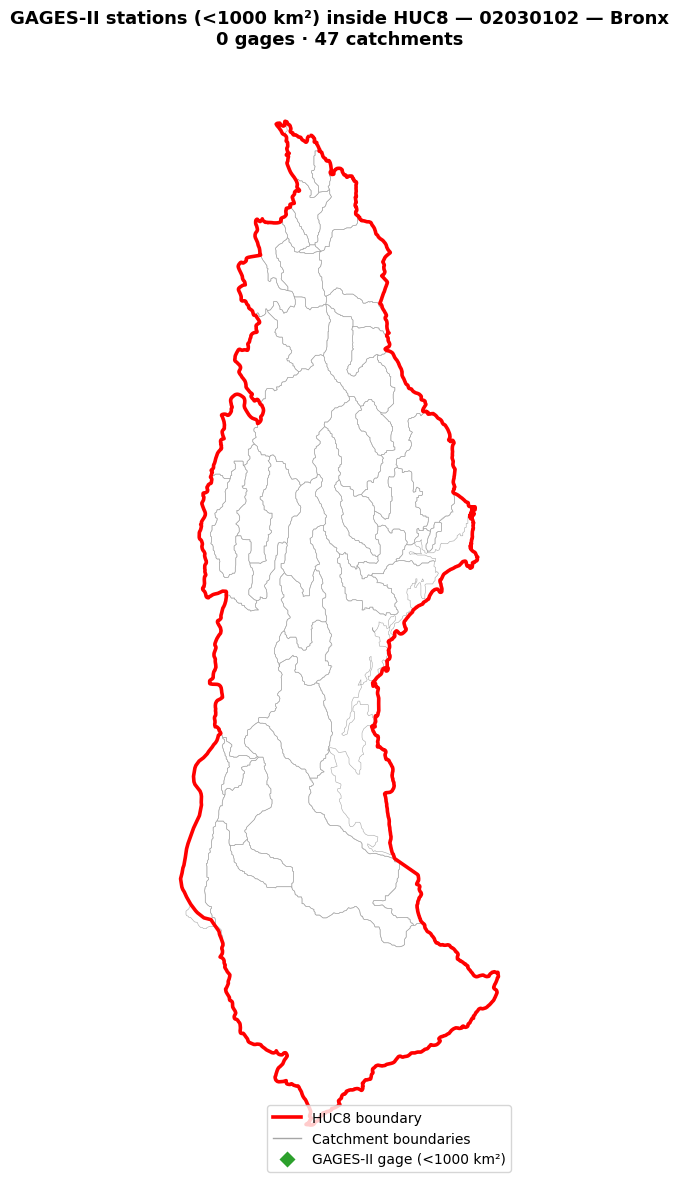


Saved -> huc8_gages2 (0 stations)


In [10]:
# # ============================================================
# # Plot gages2_lt1000km2 stations inside the selected HUC8,
# # overlaid on HUC8 boundary + hydrofabric catchment boundaries.
# #
# # Requires: selected_huc8, catchments_master, cat_centroids, target_crs
# # ============================================================
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D

# assert selected_huc8 is not None, "\u274c Confirm a HUC8 in the selector cell first."

# GAGES2_CSV = Path("gages2_lt1000km2.csv")
# assert GAGES2_CSV.exists(), f"\u274c Not found: {GAGES2_CSV.resolve()}"

# sel = selected_huc8
# sel_label = sel["_label"].iloc[0]
# sel_geom = sel.geometry.iloc[0]

# # -----------------------------
# # 1. Load gages2 and build point layer
# # -----------------------------
# g2 = pd.read_csv(GAGES2_CSV)
# for c in ["LAT_GAGE", "LNG_GAGE"]:
#     g2[c] = pd.to_numeric(g2[c], errors="coerce")
# g2 = g2.dropna(subset=["LAT_GAGE", "LNG_GAGE"]).copy()

# g2_gdf = gpd.GeoDataFrame(
#     g2,
#     geometry=gpd.points_from_xy(g2["LNG_GAGE"], g2["LAT_GAGE"]),
#     crs="EPSG:4326",
# ).to_crs(target_crs)

# # 2. Keep only those inside the HUC8
# g2_in = g2_gdf[g2_gdf.within(sel_geom)].copy()

# # 3. Hydrofabric catchments inside the HUC8 (centroid-in, for boundary overlay)
# inside_ids = cat_centroids[cat_centroids.within(sel_geom)]["divide_id"]
# cats_in = catchments_master[catchments_master["divide_id"].isin(inside_ids)]

# print(f"HUC8: {sel_label}")
# print(f"gages2 stations total       : {len(g2_gdf):,}")
# print(f"gages2 inside this HUC8      : {len(g2_in):,}")
# print(f"catchments inside (overlay)  : {len(cats_in):,}")

# # ============================================================
# # 4. Plot
# # ============================================================
# fig, ax = plt.subplots(figsize=(12, 12))
# fig.patch.set_facecolor("white")

# # catchment boundaries overlay
# cats_in.boundary.plot(ax=ax, color="0.65", linewidth=0.4, zorder=2)

# # HUC8 boundary
# sel.boundary.plot(ax=ax, color="red", linewidth=2.6, zorder=5)

# # gages2 stations inside
# g2_in.plot(ax=ax, color="tab:green", markersize=55, marker="D",
#            edgecolor="white", linewidth=0.5, zorder=6)

# minx, miny, maxx, maxy = sel.total_bounds
# padx = (maxx - minx) * 0.05 + 200
# pady = (maxy - miny) * 0.05 + 200
# ax.set_xlim(minx - padx, maxx + padx)
# ax.set_ylim(miny - pady, maxy + pady)

# ax.set_title(
#     f"GAGES-II stations (<1000 km\u00b2) inside HUC8 \u2014 {sel_label}\n"
#     f"{len(g2_in):,} gages \u00b7 {len(cats_in):,} catchments",
#     fontsize=13, fontweight="bold"
# )
# ax.set_axis_off()
# ax.set_aspect("equal")

# ax.legend(
#     handles=[
#         Line2D([0], [0], color="red", lw=2.6, label="HUC8 boundary"),
#         Line2D([0], [0], color="0.65", lw=1.0, label="Catchment boundaries"),
#         Line2D([0], [0], marker="D", color="none", markerfacecolor="tab:green",
#                markeredgecolor="white", markersize=9, label="GAGES-II gage (<1000 km\u00b2)"),
#     ],
#     loc="lower right", frameon=True, fontsize=10
# )

# plt.tight_layout()
# plt.show()

# # save for downstream
# huc8_gages2 = g2_in
# print(f"\nSaved -> huc8_gages2 ({len(g2_in):,} stations)")

Catchments inside HUC8: 47
Flowpaths: 42
Nexus: 33
Storm centroids inside : 0
OLD gages inside       : 0
NEW gages inside       : 0 of 12


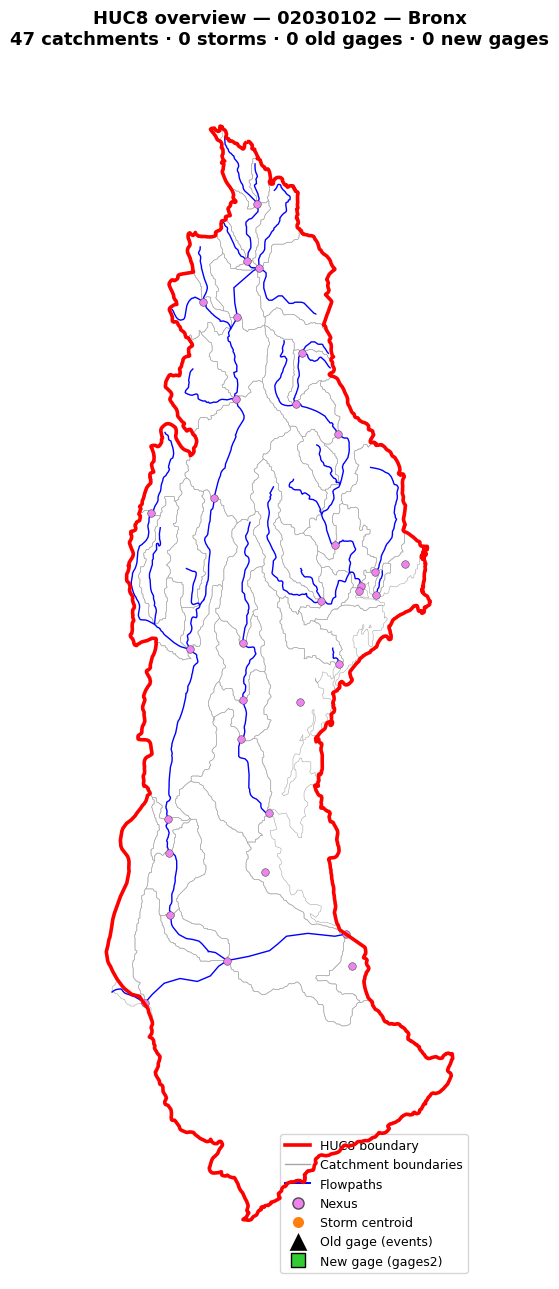


Saved -> huc8_catchments_overview (47), huc8_new_gages (0)


In [11]:
# # ============================================================
# # HUC8 overview map:
# #   - catchment boundaries (overlay)
# #   - flowpaths  (blue lines)
# #   - nexus      (violet)
# #   - storm centroids   (events CSV)  inside HUC8
# #   - OLD gages         (events CSV)  inside HUC8
# #   - NEW gages         (gages2 CSV)  inside HUC8
# #
# # Requires: selected_huc8, catchments_master, cat_centroids,
# #           events (with in_huc8 flags), flowpaths, nexus
# # ============================================================
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# import matplotlib.pyplot as plt
# from pathlib import Path
# from matplotlib.lines import Line2D

# assert selected_huc8 is not None, "\u274c Confirm a HUC8 in the selector cell first."

# sel = selected_huc8
# sel_label = sel["_label"].iloc[0]
# sel_geom = sel.geometry.iloc[0]

# # -----------------------------
# # 1. Catchments whose center is inside the HUC8
# # -----------------------------
# inside_ids = cat_centroids[cat_centroids.within(sel_geom)]["divide_id"]
# huc8_cats = catchments_master[
#     catchments_master["divide_id"].isin(inside_ids)
# ].copy()
# sel_divide_ids = set(huc8_cats["divide_id"].astype(str))
# print(f"Catchments inside HUC8: {len(huc8_cats):,}")

# # -----------------------------
# # 2. Flowpaths for those catchments (network: divide_id -> wb- id)
# # -----------------------------
# net_sub = network[network["divide_id"].astype(str).isin(sel_divide_ids)]
# fp_ids = net_sub["id"].astype(str).unique()
# fp_geom = flowpaths[flowpaths["id"].astype(str).isin(fp_ids)].copy()
# if len(fp_geom) and fp_geom.crs != target_crs:
#     fp_geom = fp_geom.to_crs(target_crs)
# print(f"Flowpaths: {len(fp_geom):,}")

# # -----------------------------
# # 3. Nexus for those catchments (catchment nexus_id = its toid)
# # -----------------------------
# nexus_geom = nexus if nexus.crs == target_crs else nexus.to_crs(target_crs)

# nex_ids = (
#     catchments_master.loc[
#         catchments_master["divide_id"].isin(huc8_cats["divide_id"]),
#         "nexus_id",
#     ].astype(str).unique()
# )
# nex_geom = nexus_geom[nexus_geom["id"].astype(str).isin(nex_ids)].copy()
# print(f"Nexus: {len(nex_geom):,}")

# # -----------------------------
# # 4. Event points inside HUC8 (storms + OLD gages from events CSV)
# # -----------------------------
# def _pts(df, lon_col, lat_col):
#     ok = df[[lon_col, lat_col]].notna().all(axis=1)
#     return gpd.GeoDataFrame(
#         df.loc[ok].copy(),
#         geometry=gpd.points_from_xy(df.loc[ok, lon_col], df.loc[ok, lat_col]),
#         crs="EPSG:4326",
#     ).to_crs(target_crs)

# storm_in = _pts(events[events["centroid_in_huc8"]], "centroid_lon", "centroid_lat")
# oldgage_in = _pts(events[events["gage_in_huc8"]], "gage_lon", "gage_lat")
# print(f"Storm centroids inside : {len(storm_in):,}")
# print(f"OLD gages inside       : {len(oldgage_in):,}")

# # -----------------------------
# # 5. NEW gages (gages2 CSV) inside HUC8
# # -----------------------------
# NEW_GAGES_CSV = Path("gages2_lt1000km2.csv")
# assert NEW_GAGES_CSV.exists(), f"\u274c Not found: {NEW_GAGES_CSV.resolve()}"

# new_gages = pd.read_csv(NEW_GAGES_CSV)
# for c in ["LAT_GAGE", "LNG_GAGE"]:
#     new_gages[c] = pd.to_numeric(new_gages[c], errors="coerce")

# newgage_all = _pts(new_gages, "LNG_GAGE", "LAT_GAGE")
# newgage_in = newgage_all[newgage_all.within(sel_geom)].copy()
# print(f"NEW gages inside       : {len(newgage_in):,} of {len(newgage_all):,}")

# # ============================================================
# # 6. Plot -- single HUC8 map
# # ============================================================
# fig, ax = plt.subplots(figsize=(13, 13))
# fig.patch.set_facecolor("white")

# # catchment boundaries (overlay)
# huc8_cats.boundary.plot(ax=ax, color="0.65", linewidth=0.4, zorder=1)

# # flowpaths in blue
# if len(fp_geom):
#     fp_geom.plot(ax=ax, color="blue", linewidth=1.0, zorder=2)

# # nexus in violet
# if len(nex_geom):
#     nex_geom.plot(ax=ax, color="violet", markersize=30, marker="o",
#                   edgecolor="0.3", linewidth=0.4, zorder=3)

# # storm centroids (orange circle)
# if len(storm_in):
#     storm_in.plot(ax=ax, color="tab:orange", markersize=55, marker="o",
#                   edgecolor="white", linewidth=0.6, zorder=5)

# # OLD gages (black triangle)
# if len(oldgage_in):
#     oldgage_in.plot(ax=ax, color="black", markersize=80, marker="^",
#                     edgecolor="white", linewidth=0.6, zorder=7)

# # NEW gages (green square)
# if len(newgage_in):
#     newgage_in.plot(ax=ax, color="limegreen", markersize=80, marker="s",
#                     edgecolor="black", linewidth=0.7, zorder=6)

# # HUC8 boundary on top
# sel.boundary.plot(ax=ax, color="red", linewidth=2.6, zorder=8)

# minx, miny, maxx, maxy = sel.total_bounds
# padx = (maxx - minx) * 0.05 + 200
# pady = (maxy - miny) * 0.05 + 200
# ax.set_xlim(minx - padx, maxx + padx)
# ax.set_ylim(miny - pady, maxy + pady)

# ax.set_title(
#     f"HUC8 overview \u2014 {sel_label}\n"
#     f"{len(huc8_cats):,} catchments \u00b7 {len(storm_in):,} storms \u00b7 "
#     f"{len(oldgage_in):,} old gages \u00b7 {len(newgage_in):,} new gages",
#     fontsize=13, fontweight="bold"
# )
# ax.set_axis_off()
# ax.set_aspect("equal")

# ax.legend(
#     handles=[
#         Line2D([0], [0], color="red", lw=2.6, label="HUC8 boundary"),
#         Line2D([0], [0], color="0.65", lw=1.0, label="Catchment boundaries"),
#         Line2D([0], [0], color="blue", lw=1.4, label="Flowpaths"),
#         Line2D([0], [0], marker="o", color="none", markerfacecolor="violet",
#                markeredgecolor="0.3", markersize=8, label="Nexus"),
#         Line2D([0], [0], marker="o", color="none", markerfacecolor="tab:orange",
#                markeredgecolor="white", markersize=9, label="Storm centroid"),
#         Line2D([0], [0], marker="^", color="none", markerfacecolor="black",
#                markeredgecolor="white", markersize=15, label="Old gage (events)"),
#         Line2D([0], [0], marker="s", color="none", markerfacecolor="limegreen",
#                markeredgecolor="black", markersize=10, label="New gage (gages2)"),
#     ],
#     loc="lower right", frameon=True, fontsize=9
# )

# plt.tight_layout()
# plt.show()

# # save for downstream
# huc8_catchments_overview = huc8_cats
# huc8_new_gages = newgage_in
# print(f"\nSaved -> huc8_catchments_overview ({len(huc8_cats):,}), "
#       f"huc8_new_gages ({len(newgage_in):,})")

In [12]:
import sys
!{sys.executable} -m pip install -q openpyxl

In [16]:
# # ============================================================
# # Export combined HUC8 table:
# #   - ALL columns of the events CSV where the STORM CENTROID is in the HUC8
# #   - extra rows: new gages (gages2) where the GAGE CENTER is in the HUC8
# #   - source column distinguishes the two; xlsx colors them differently
# #
# # Requires: selected_huc8, target_crs, events, new_gages
# #           (or it will reload the CSVs)
# # ============================================================
# from openpyxl import Workbook
# from openpyxl.styles import Font, PatternFill
# from openpyxl.utils.dataframe import dataframe_to_rows

# assert selected_huc8 is not None, "\u274c Confirm a HUC8 first."

# sel = selected_huc8
# sel_label = sel["_label"].iloc[0]
# sel_geom = sel.geometry.iloc[0]
# huc8_code = sel_label.split(" \u2014 ")[0]

# # -----------------------------
# # 0. Reload source CSVs if needed
# # -----------------------------
# if "events" not in globals():
#     events = pd.read_csv("final_events (6).csv")
# if "new_gages" not in globals():
#     new_gages = pd.read_csv("gages2_lt1000km2.csv")

# # -----------------------------
# # 1. Events with STORM CENTROID inside the HUC8 (all columns kept)
# # -----------------------------
# ev = events.copy()
# for c in ["centroid_lat", "centroid_lon"]:
#     ev[c] = pd.to_numeric(ev[c], errors="coerce")

# ev_ok = ev[["centroid_lon", "centroid_lat"]].notna().all(axis=1)
# ev_pts = gpd.GeoDataFrame(
#     ev.loc[ev_ok].copy(),
#     geometry=gpd.points_from_xy(ev.loc[ev_ok, "centroid_lon"],
#                                 ev.loc[ev_ok, "centroid_lat"]),
#     crs="EPSG:4326",
# ).to_crs(target_crs)

# events_in = ev.loc[ev_pts.index[ev_pts.within(sel_geom)]].copy()
# events_in.insert(0, "source", "event_storm_in_huc8")
# print(f"Events (storm centroid in HUC8): {len(events_in):,}")

# # -----------------------------
# # 2. New gages with GAGE CENTER inside the HUC8 (all columns kept)
# # -----------------------------
# ng = new_gages.copy()
# for c in ["LAT_GAGE", "LNG_GAGE"]:
#     ng[c] = pd.to_numeric(ng[c], errors="coerce")

# ng_ok = ng[["LNG_GAGE", "LAT_GAGE"]].notna().all(axis=1)
# ng_pts = gpd.GeoDataFrame(
#     ng.loc[ng_ok].copy(),
#     geometry=gpd.points_from_xy(ng.loc[ng_ok, "LNG_GAGE"],
#                                 ng.loc[ng_ok, "LAT_GAGE"]),
#     crs="EPSG:4326",
# ).to_crs(target_crs)

# newgages_in = ng.loc[ng_pts.index[ng_pts.within(sel_geom)]].copy()
# newgages_in.insert(0, "source", "new_gage_in_huc8")
# print(f"New gages (gage center in HUC8): {len(newgages_in):,}")

# # -----------------------------
# # 3. Combine (outer-align columns; events first, new gages appended)
# # -----------------------------
# combined = pd.concat([events_in, newgages_in], ignore_index=True, sort=False)
# print(f"Combined rows: {len(combined):,} | columns: {combined.shape[1]}")

# # -----------------------------
# # 4. Write CSV
# # -----------------------------
# out_csv = Path(f"huc8_{huc8_code}_events_and_gages.csv")
# combined.to_csv(out_csv, index=False)
# print(f"\u2705 CSV  -> {out_csv.resolve()}")

# # -----------------------------
# # 5. Write color-coded XLSX (events vs new gages)
# # -----------------------------
# EVENT_FILL = PatternFill("solid", fgColor="DDEBF7")   # light blue
# NEWGAGE_FILL = PatternFill("solid", fgColor="E2EFDA")  # light green
# HEADER_FILL = PatternFill("solid", fgColor="404040")

# wb = Workbook()
# ws = wb.active
# ws.title = f"HUC8_{huc8_code}"

# for r in dataframe_to_rows(combined, index=False, header=True):
#     ws.append(r)

# # header style
# for cell in ws[1]:
#     cell.font = Font(name="Arial", bold=True, color="FFFFFF")
#     cell.fill = HEADER_FILL

# # body font + per-row fill by source (source is column 1)
# src_col = list(combined.columns).index("source") + 1
# for row in ws.iter_rows(min_row=2):
#     for cell in row:
#         cell.font = Font(name="Arial")
#     fill = (EVENT_FILL if row[src_col - 1].value == "event_storm_in_huc8"
#             else NEWGAGE_FILL)
#     for cell in row:
#         cell.fill = fill

# ws.freeze_panes = "A2"

# out_xlsx = Path(f"huc8_{huc8_code}_events_and_gages.xlsx")
# wb.save(out_xlsx)
# print(f"\u2705 XLSX -> {out_xlsx.resolve()}  "
#       f"(events = light blue, new gages = light green)")

# # save in memory too
# huc8_combined_table = combined

Events (storm centroid in HUC8): 5,388
New gages (gage center in HUC8): 12
Combined rows: 5,400 | columns: 27
✅ CSV  -> /home/jovyan/Group_Project/huc8_03020201_events_and_gages.csv
✅ XLSX -> /home/jovyan/Group_Project/huc8_03020201_events_and_gages.xlsx  (events = light blue, new gages = light green)


# Section 5 \u2014 Storm \u2192 gage network analysis

For each HUC8 storm, find the USGS gages connected to it up/downstream through
the flowpath network. This builds the directed graph `G` (from `network`) and
`valid_storms` / `gages_indexed` / `results_df` \u2014 **`valid_storms`, `G`, and
`gages_indexed` are what Notebook 3 needs** to associate each event with its
recording gage's upstream contributing catchments.

In [17]:
# import sys
# !{sys.executable} -m pip install -q networkx tqdm


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [18]:
# # ============================================================
# # Upstream/downstream USGS gages for the HUC8-selected storms
# # (adapted from usgs_for_ff: flood_points->events, gages->new_gages,
# #  divides->catchments_master)
# #
# # Requires: selected_huc8, catchments_master, network, flowpaths,
# #           target_crs   (events / new_gages reloaded if needed)
# # ============================================================
# import numpy as np
# import pandas as pd
# import geopandas as gpd
# import networkx as nx
# from pathlib import Path
# from tqdm.auto import tqdm

# assert selected_huc8 is not None, "\u274c Confirm a HUC8 first."
# sel = selected_huc8
# sel_geom = sel.geometry.iloc[0]
# sel_label = sel["_label"].iloc[0]
# huc8_code = sel_label.split(" \u2014 ")[0]

# # Snap/search all gages (so a connected gage just outside the HUC8 isn't lost).
# # Set True to restrict gages to those inside the HUC8.
# GAGES_HUC8_ONLY = False

# # -----------------------------
# # 0. Reload source tables if needed
# # -----------------------------
# if "events" not in globals():
#     events = pd.read_csv("final_events (6).csv")
# if "new_gages" not in globals():
#     new_gages = pd.read_csv("gages2_lt1000km2.csv")
# if flowpaths.crs != target_crs:
#     flowpaths = flowpaths.to_crs(target_crs)

# # -----------------------------
# # 1. Storms (unique) whose centroid is inside the HUC8
# # -----------------------------
# ev = events.copy()
# for c in ["centroid_lat", "centroid_lon"]:
#     ev[c] = pd.to_numeric(ev[c], errors="coerce")
# ev = ev.dropna(subset=["centroid_lat", "centroid_lon"])
# ev = ev.drop_duplicates(subset="storm_index")

# storm_gdf = gpd.GeoDataFrame(
#     ev,
#     geometry=gpd.points_from_xy(ev["centroid_lon"], ev["centroid_lat"]),
#     crs="EPSG:4326",
# ).to_crs(target_crs)

# storm_gdf = storm_gdf[storm_gdf.within(sel_geom)].copy()
# print(f"Storms with centroid in HUC8: {len(storm_gdf):,}")

# # -----------------------------
# # 2. Assign storm centroid -> divide -> flowpath
# # -----------------------------
# # events CSV already has its own storm_divide_id / gage_divide_id columns --
# # drop them so the spatial-join column doesn't collide.
# storm_gdf = storm_gdf.drop(
#     columns=[c for c in ["storm_divide_id", "gage_divide_id"] if c in storm_gdf.columns]
# )

# storm_div = gpd.sjoin(
#     storm_gdf,
#     catchments_master[["divide_id", "geometry"]],
#     how="left", predicate="within",
# ).rename(columns={"divide_id": "storm_divide_id"})
# storm_div = storm_div[~storm_div.index.duplicated(keep="first")]

# # divide_id -> flowpath id (wb-...) lookup from network
# divide_to_flowpath = (
#     network[["divide_id", "id"]].dropna()
#     .drop_duplicates(subset="divide_id")
#     .set_index("divide_id")["id"]
# )
# storm_div["storm_flowpath_id"] = storm_div["storm_divide_id"].map(divide_to_flowpath)

# valid_storms = storm_div[storm_div["storm_flowpath_id"].notna()].copy()
# print(f"Storms mapped to a flowpath: {len(valid_storms):,} / {len(storm_div):,}")

# # -----------------------------
# # 3. Snap gages to nearest flowpath
# # -----------------------------
# ng = new_gages.copy()
# for c in ["LAT_GAGE", "LNG_GAGE"]:
#     ng[c] = pd.to_numeric(ng[c], errors="coerce")
# ng = ng.dropna(subset=["LAT_GAGE", "LNG_GAGE"])

# gages_gdf = gpd.GeoDataFrame(
#     ng,
#     geometry=gpd.points_from_xy(ng["LNG_GAGE"], ng["LAT_GAGE"]),
#     crs="EPSG:4326",
# ).to_crs(target_crs)

# if GAGES_HUC8_ONLY:
#     gages_gdf = gages_gdf[gages_gdf.within(sel_geom)].copy()

# gages_indexed = gpd.sjoin_nearest(
#     gages_gdf, flowpaths[["id", "geometry"]],
#     how="left", distance_col="gage_snap_dist_m",
# ).rename(columns={"id": "gage_flowpath_id"})
# gages_indexed = gages_indexed[~gages_indexed.index.duplicated(keep="first")]
# print(f"Gages snapped: {gages_indexed['gage_flowpath_id'].notna().sum():,} "
#       f"/ {len(gages_indexed):,}")

# # -----------------------------
# # 4. Directed network graph (id -> toid)
# # -----------------------------
# edges = network.dropna(subset=["id", "toid"]).copy()
# edges = edges[(edges["id"].astype(str).str.strip() != "") &
#               (edges["toid"].astype(str).str.strip() != "")]
# G = nx.from_pandas_edgelist(edges, source="id", target="toid",
#                             create_using=nx.DiGraph())
# print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# # -----------------------------
# # 5. For each HUC8 storm, find connected gages up/downstream
# # -----------------------------
# results = []
# for idx, flood in tqdm(valid_storms.iterrows(), total=len(valid_storms)):
#     fp = flood["storm_flowpath_id"]
#     if fp not in G:
#         continue
#     up = nx.ancestors(G, fp);   up.add(fp)
#     down = nx.descendants(G, fp); down.add(fp)

#     for rel, fset in [("upstream", up), ("downstream", down)]:
#         hits = gages_indexed[gages_indexed["gage_flowpath_id"].isin(fset)]
#         for _, g in hits.iterrows():
#             results.append({
#                 "storm_index": flood["storm_index"],
#                 "storm_flowpath_id": fp,
#                 "storm_divide_id": flood["storm_divide_id"],
#                 "storm_lat": flood["centroid_lat"],
#                 "storm_lon": flood["centroid_lon"],
#                 "STAID": g["STAID"],
#                 "STATID": g.get("STATID", None),
#                 "DRAIN_SQKM": g.get("DRAIN_SQKM", None),
#                 "gage_lat": g["LAT_GAGE"],
#                 "gage_lon": g["LNG_GAGE"],
#                 "gage_flowpath_id": g["gage_flowpath_id"],
#                 "gage_snap_dist_m": g["gage_snap_dist_m"],
#                 "relationship": rel,
#             })

# results_df = pd.DataFrame(results)
# out_csv = Path(f"huc8_{huc8_code}_storm_gage_upstream_downstream.csv")
# results_df.to_csv(out_csv, index=False)
# print(f"\n\u2705 {len(results_df):,} storm-gage pairs -> {out_csv.resolve()}")
# if len(results_df):
#     print(results_df["relationship"].value_counts())

Storms with centroid in HUC8: 5,388
Storms mapped to a flowpath: 5,388 / 5,388
Gages snapped: 12 / 12
Graph: 1,233,091 nodes, 1,233,090 edges


  0%|          | 0/5388 [00:00<?, ?it/s]


✅ 13,429 storm-gage pairs -> /home/jovyan/Group_Project/huc8_03020201_storm_gage_upstream_downstream.csv
relationship
upstream      6877
downstream    6552
Name: count, dtype: int64


## 5.1 Save outputs for Notebook 3

Notebook 3 needs: the selected HUC8/catchments, the flagged event catalog, and
the storm->gage network results (`valid_storms`, `gages_indexed`). It rebuilds
`G` itself from `network.parquet` (cheap -- a few seconds) rather than us trying
to serialize a NetworkX graph, and it reads the CONUS crosswalk straight from
`mrms_crosswalk_cache/mrms_hf_crosswalk_conus.parquet` (already written above).

In [19]:
# OUT_DIR2 = Path("huc8_selection_outputs")
# OUT_DIR2.mkdir(exist_ok=True)

# selected_huc8.to_parquet(OUT_DIR2 / "selected_huc8.parquet")
# huc8_catchments.to_parquet(OUT_DIR2 / "huc8_catchments.parquet")
# events.to_csv(OUT_DIR2 / "events_flagged.csv", index=False)
# valid_storms.drop(columns="geometry").to_csv(OUT_DIR2 / "valid_storms.csv", index=False)
# gages_indexed.drop(columns="geometry").to_csv(OUT_DIR2 / "gages_indexed.csv", index=False)
# results_df.to_csv(OUT_DIR2 / "storm_gage_results.csv", index=False)

# with open(OUT_DIR2 / "huc8_code.txt", "w") as f:
#     f.write(huc8_code)

# print("Saved to", OUT_DIR2.resolve())
# for f in sorted(OUT_DIR2.iterdir()):
#     print(" -", f.name, f"({f.stat().st_size / 1e6:.2f} MB)")

Saved to /home/jovyan/Group_Project/huc8_selection_outputs
 - events_flagged.csv (1.16 MB)
 - gages_indexed.csv (0.00 MB)
 - huc8_catchments.parquet (0.71 MB)
 - huc8_code.txt (0.00 MB)
 - selected_huc8.parquet (0.23 MB)
 - storm_gage_results.csv (1.64 MB)
 - valid_storms.csv (1.30 MB)


## Notebook 2 -- done \u2705

- Full-CONUS MRMS\u2194HydroFabric crosswalk built and cached at
  `mrms_crosswalk_cache/mrms_hf_crosswalk_conus.parquet`, sanity-checked, and
  visually verified.
- A HUC8 is selected, its flood events are filtered, and each storm is traced
  to its recording gage and that gage's connected up/downstream gages.
- Everything Notebook 3 needs is saved to `huc8_selection_outputs/`.

**Next: Notebook 3** -- build the per-event MRMS timestamp manifest, download
2-minute PrecipRate files, restrict the crosswalk to event-relevant catchments
(fractional/area-weighted), and convert to 15-minute catchment rainfall series.